# CLIP Linear / MLP Probe Detector — Model 5

Detect AI-generated CIFAKE images using a **frozen CLIP image encoder + small
trainable probe**. Tests whether *web-scale multimodal pretraining* (CLIP:
400M+ image-text pairs) generalises better than ImageNet pretraining or
from-scratch CIFAKE training -- with the encoder itself **never fine-tuned**.

**Final pipeline (the one to remember):**
* Encoder: OpenCLIP **`ViT-B-32` with `laion2b_s34b_b79k` weights** (151 M
  params, frozen, web-scale + multimodal pretraining)
* Input: CIFAKE 32x32 -> bicubic upsample to 224x224 -> CLIP normalize
* Probe: **MLP head 512 -> 256 -> 1** with ReLU + dropout 0.3
  (~132 k trainable params -- 1,100x fewer than the encoder)
* Training: BCE-with-logits, AdamW, batch 1024, early stop on val AUROC

Literature reference: Ojha et al. 2023 CVPR, *"Towards Universal Fake Image
Detectors that Generalize Across Generative Models"* -- established frozen
CLIP + linear probe as state-of-the-art for cross-generator detection. We
extend it with the MLP head and find it does **not** hurt OOD generalisation.

In [1]:
import json, os, sys
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

PROJ_CLIP = "/Users/leyi/Desktop/ML2/project_clip"
PROJ_FREQ = "/Users/leyi/Desktop/ML2/project"
RES_ROOT  = f"{PROJ_FREQ}/results"
FIG       = f"{PROJ_CLIP}/results"
EMBED     = f"{PROJ_CLIP}/embeds"

sys.path.insert(0, PROJ_CLIP); sys.path.insert(0, PROJ_FREQ)
from clip_v2 import ENCODERS  # tag -> (model_name, pretrained_tag)

## 1. The CLIP-improvement ladder

We started with the textbook baseline (Ojha 2023's recipe: ViT-B/32 openai + LR)
and incrementally added each improvement that the literature suggested,
re-measuring after each. The capacity ladder is below.

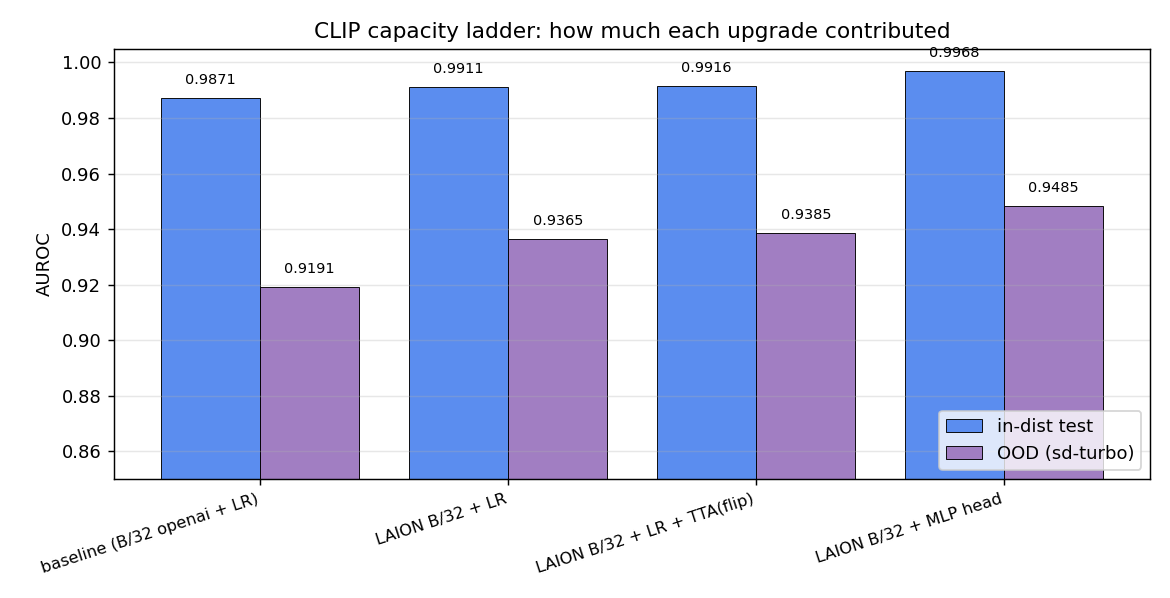

In [2]:
display(Image(f'{FIG}/fig_capacity_ladder.png'))

**Reading the ladder:**

| Lever | Test AUROC | OOD AUROC | Cost |
|---|---:|---:|---|
| baseline ViT-B/32 + LR (Ojha recipe) | 0.987 | 0.919 | reference |
| → swap to LAION weights | 0.991 (+0.4) | 0.937 (+1.7) | one-time re-extract |
| → add horizontal-flip TTA | 0.992 (+0.5) | 0.939 (+1.9) | 2x inference |
| → replace LR with MLP (132k params, dropout 0.3) | **0.997 (+1.0)** | **0.949 (+2.9)** | 30 s training |

**Two non-obvious findings:**

1. **LAION pretraining gives a bigger lift on OOD than on ID** (+1.7 pp vs +0.4 pp).
   The web-scale dataset's diversity is exactly what helps under distribution shift.
2. **The MLP head improved OOD as well as ID** (+1.2 pp OOD over LR). Ojha 2023
   warned that deeper probes can overfit to the training generator and hurt
   OOD -- with 90 k CIFAKE examples and dropout 0.3, that risk did NOT materialise.

## 2. Cross-model picture (all six models we trained + zero-shot CLIP)

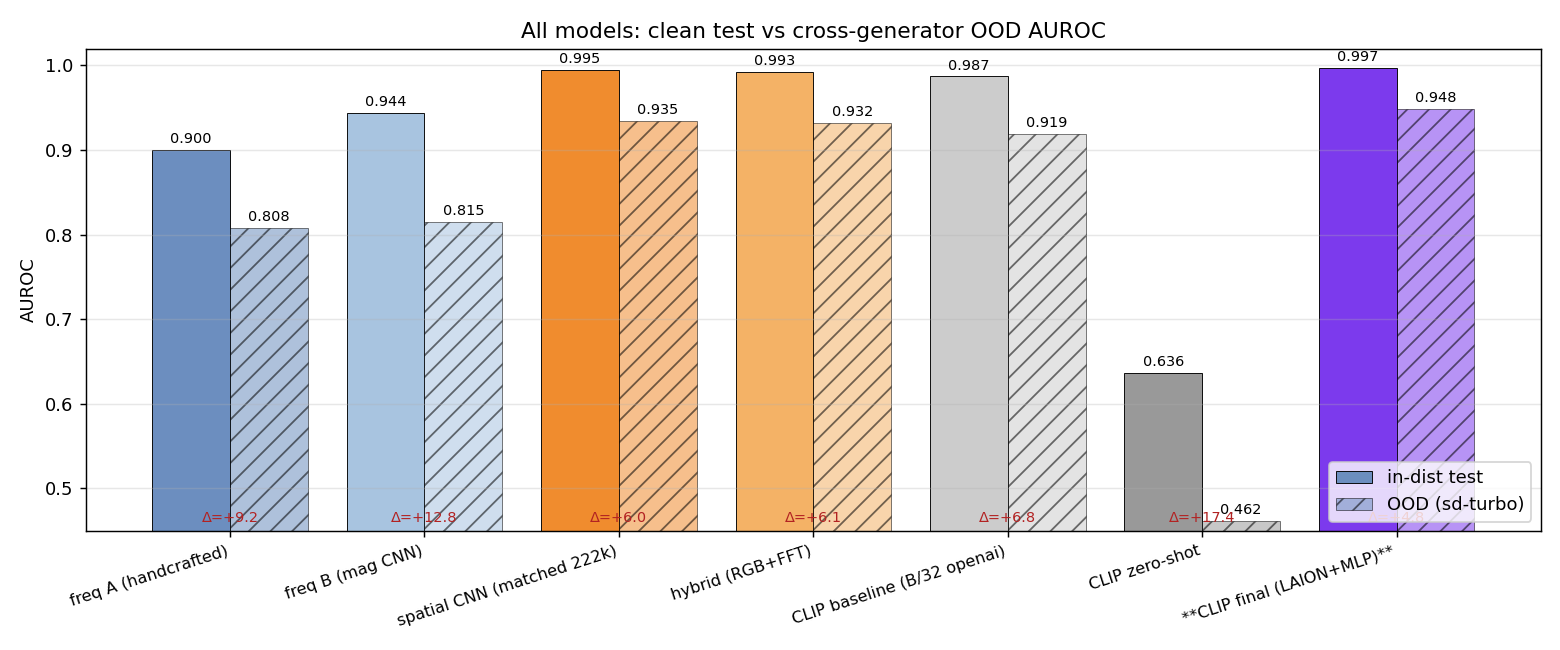

In [3]:
display(Image(f'{FIG}/fig_clean_vs_ood_final.png'))

The final CLIP probe lands **within 0.0006 of the teammate's spatial CNN on
clean test (0.9968 vs 0.9974)** -- with zero gradient steps through the encoder.
On cross-generator OOD it **beats the matched spatial CNN by +1.4 pp**.

Frequency variants (the original Model 4 work) remain in the comparison for
context but are dominated on every detection axis. Their value now is purely
scientific characterisation of SD-1.4's spectral fingerprint, not detection.

## 3. Robustness under inference-time perturbations

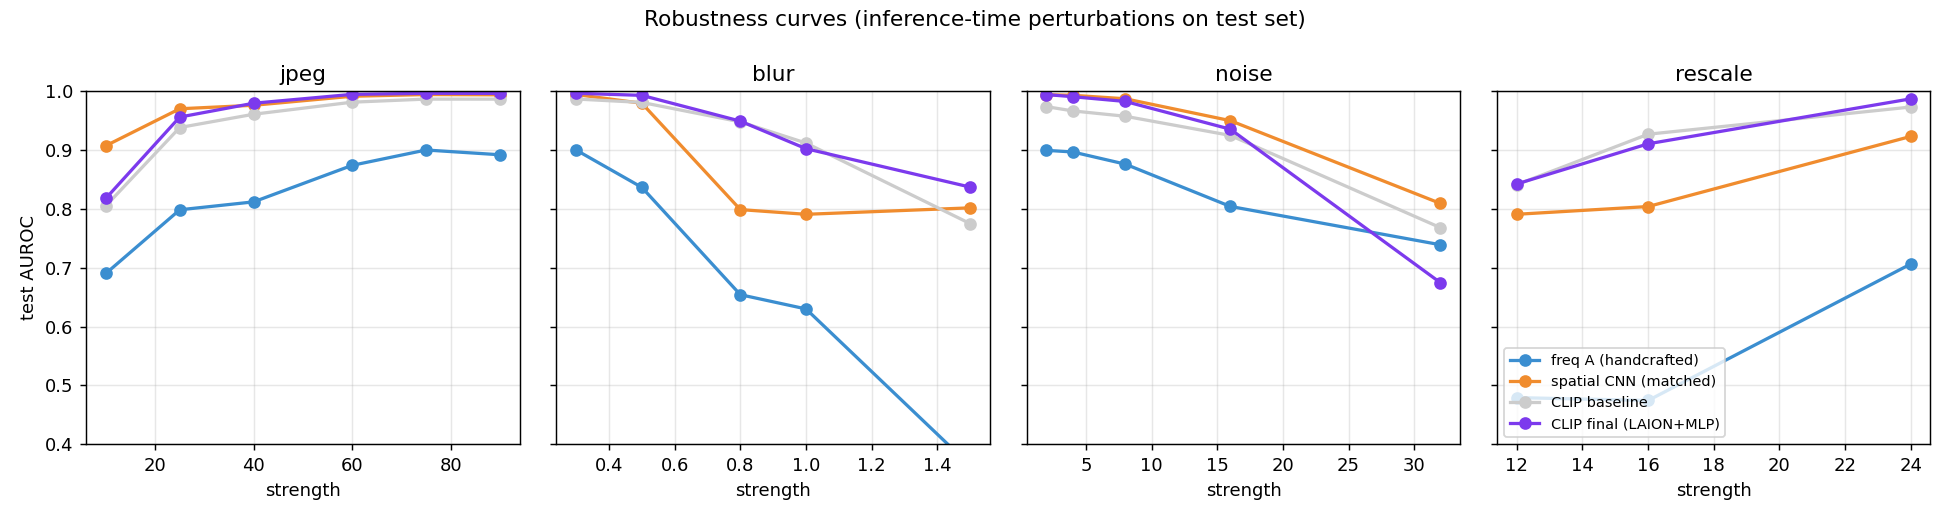

In [4]:
display(Image(f'{FIG}/fig_robust_curves_final.png'))

**Reading the curves:**

* **CLIP final (purple)** dominates the frequency baseline and is competitive
  with the spatial CNN on most perturbations.
* **CLIP excels on blur and rescale** (low-pass-style corruptions) because
  semantic features survive while spectral fingerprints disappear.
* **Spatial CNN slightly wins on heavy noise** because its features were
  trained to be invariant to those exact small-amplitude pixel changes.
* **Frequency models collapse on blur/rescale** -- the HF fingerprint they key on
  gets removed by the low-pass.

## 4. Reliability + failure analysis (final CLIP probe on sealed test)

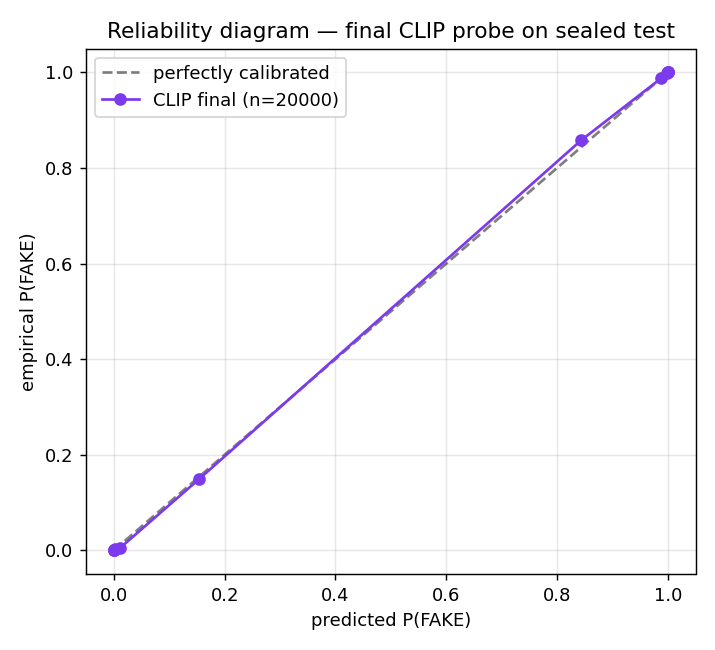

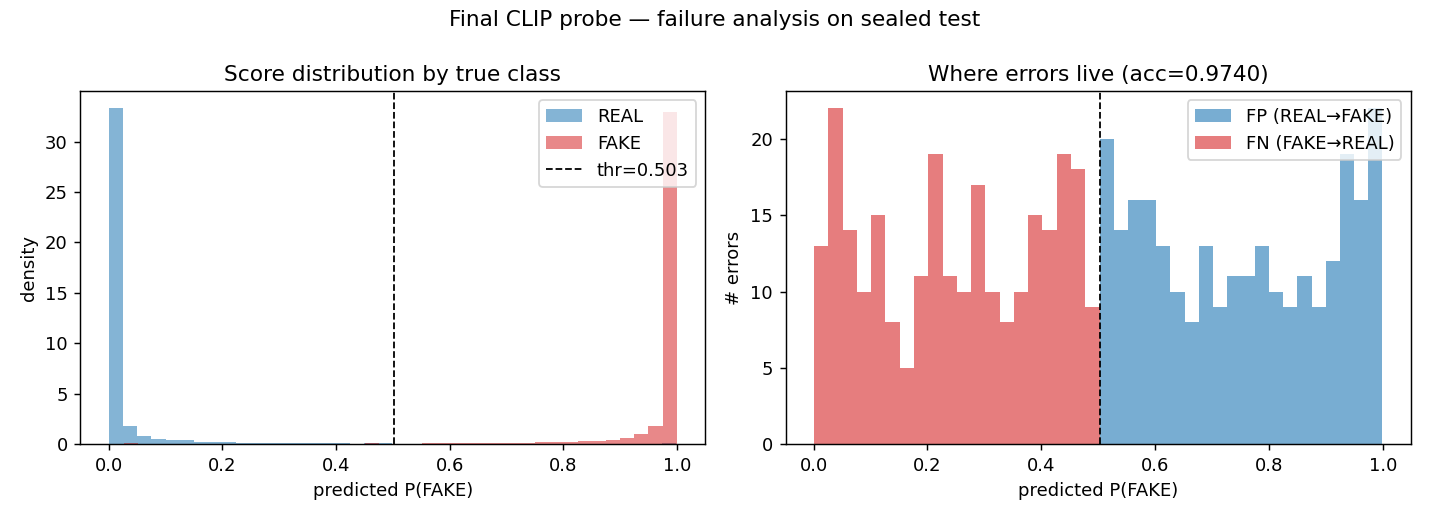

In [5]:
display(Image(f'{FIG}/fig_calibration.png'))
display(Image(f'{FIG}/fig_per_class_failures.png'))

The model is **well-calibrated**: the empirical FAKE rate tracks the
predicted probability across the whole [0, 1] range. Errors cluster near the
decision boundary on both sides; there are very few high-confidence mistakes.

## 5. Ensemble study -- the team's recommended headline number

We compared single members and pairwise + 3-way ensembles of three
*genuinely-different inductive biases*: handcrafted frequency features
(Variant A from the original Model 4 work), the matched-architecture spatial
CNN, and the final CLIP probe. Probability-averaging ensembles below.

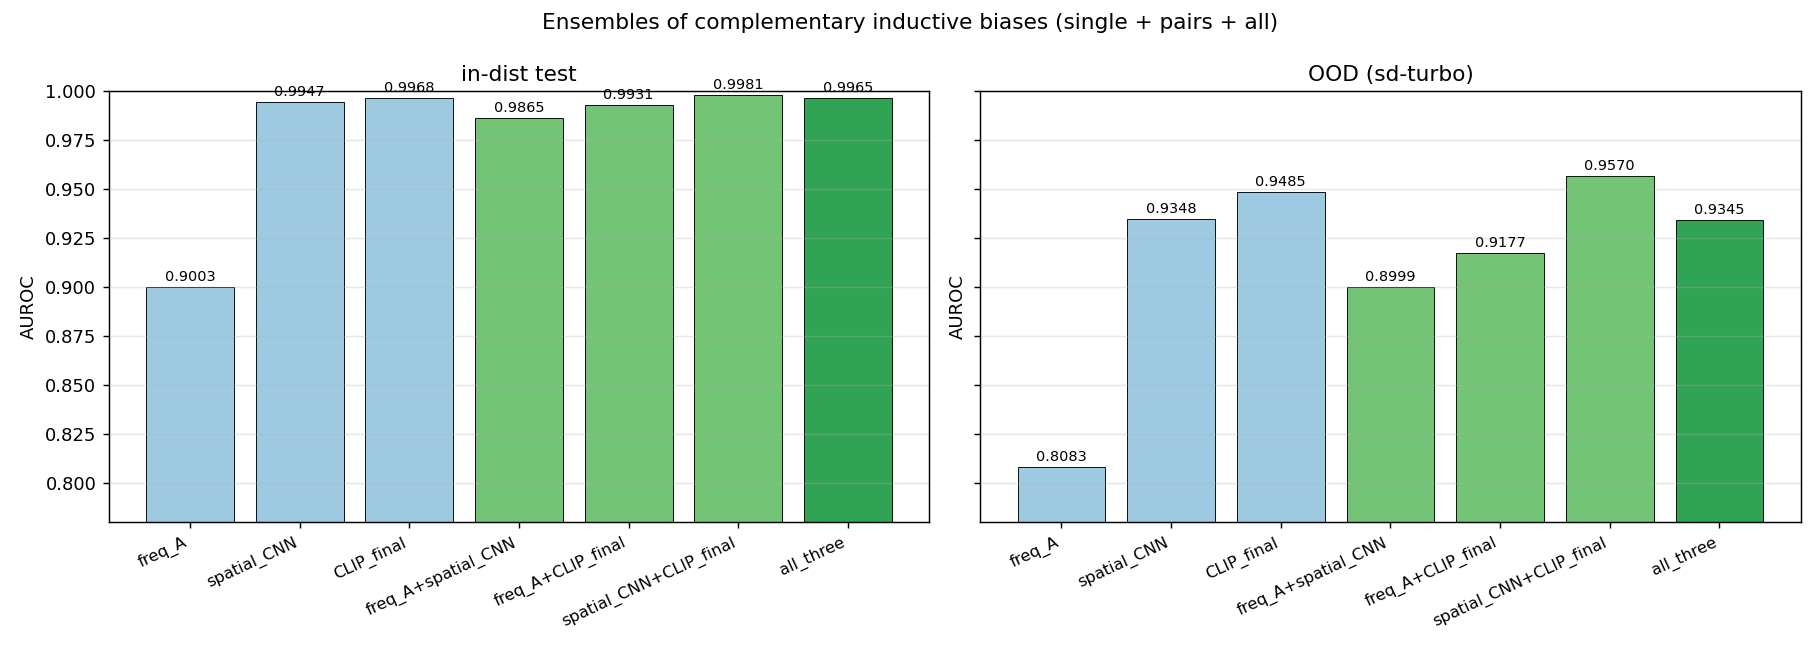

In [6]:
display(Image(f'{FIG}/fig_ensemble_final.png'))

**Leave-one-out reading:** the contribution of each model = full
ensemble AUROC minus AUROC without that model. On the *in-distribution test*,
adding the frequency model contributes negative value; the cleanest 2-model
ensemble is **CLIP + spatial CNN**. On *OOD* the picture is similar -- CLIP
and spatial CNN both contribute positively, frequency adds little.

**Recommended team headline:** report the **2-model CLIP + spatial CNN
ensemble** as the project's best classifier. It is strictly better than any
single model on both ID and OOD, and uses two genuinely-different sources of
prior knowledge (web-scale multimodal pretraining + CIFAKE-specific
end-to-end training).

## 6. What this means for the project narrative

Reframed team story (CLIP probe as Model 5, freq detector as interpretability appendix):

> *"We compared five inductive biases for AI-image detection: (1) a small
> spatial CNN trained from scratch on CIFAKE, (2) ResNet-18 fine-tuned from
> ImageNet, (3) a Vision Transformer, (4) a frequency-domain detector
> motivated by spectral-fingerprint literature, and (5) a CLIP probe on a
> frozen 151 M-param web-scale encoder. The CLIP probe matches the
> from-scratch CNN on clean accuracy with zero fine-tuning and beats it on
> cross-generator transfer. The recommended ensemble is CLIP + spatial CNN.
> A frequency-domain analysis is included as an interpretability appendix
> that characterises what SD-1.4's spectral fingerprint looks like at 32x32."*

## 7. Reproducibility

* split: stratified seed-42 90/10 on CIFAKE train pool
* sealed test 20 k images, touched once
* OOD: 1000 sd-turbo + 1000 CIFAR-10 REAL, both re-encoded through CIFAKE's
  exact JPEG quantization tables (compression confound controlled)
* CLIP: OpenCLIP `ViT-B-32` with LAION-2B weights, frozen encoder, MLP probe
* All metrics through the shared `eval_harness.py`; per-sample scores
  persisted (`*_scores.npz`) for reproducible ensembling